In [ ]:
# Load an image (pixels = RGB values)
# Use K-Means to find 8 most important colors
# Replace all pixels with nearest color
# Result: Compressed image looks similar but uses 8 colors instead of 256K

# Step 1: Load an image

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [12]:
from PIL import Image
import numpy as np

# Use any image you have, or create one
image=np.random.randint(0, 256, size=(200, 200, 3), dtype=np.uint8)
# This creates a colorful random 200x200 image

image.shape
# (200, 200, 3) = height × width × RGB

(200, 200, 3)

What does this do?

Each pixel = 3 numbers (Red 0-255, Green 0-255, Blue 0-255)
200×200 = 40,000 pixels total

In [4]:
# Reshape (200, 200, 3) → (40000, 3)
pixels = image.reshape(-1, 3)
print("Pixels shape:", pixels.shape)

Pixels shape: (40000, 3)


image.shape = (200, 200, 3)
Total pixels = 200 × 200 × 3 = 120,000

# When you do reshape(-1, 3):
# NumPy thinks: "I need 3 columns, and total is 120,000"
# So: -1 = 120,000 ÷ 3 = 40,000 rows

# Result: (40000, 3)

C:\Users\k9481\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\k9481\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\k9481\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\k9481\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

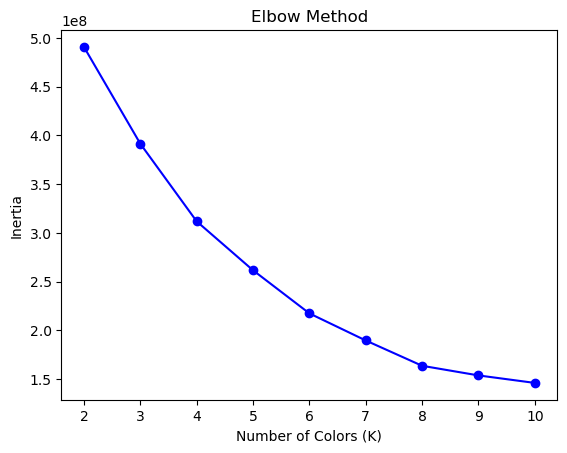

In [7]:
inertias = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(pixels)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(2, 11), inertias, 'bo-')
plt.xlabel('Number of Colors (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

    #k=7

In [8]:
kmeans = KMeans(n_clusters=7, n_init=10, random_state=42)
kmeans.fit(pixels)

print("Cluster centers shape:", kmeans.cluster_centers_.shape)
print("Cluster centers (8 colors):")
print(kmeans.cluster_centers_)

Cluster centers shape: (7, 3)
Cluster centers (8 colors):
[[ 59.39614449  76.14345259 193.72143105]
 [195.17831126 192.31754967  78.39569536]
 [ 62.98920086  63.9996073   63.57019438]
 [195.46743095  76.73041515 193.84193156]
 [124.97001764 202.68061568 203.67596601]
 [189.63043066  62.50578638  64.42003415]
 [ 59.27275838 193.46423682  78.42967146]]


In [9]:
# Get cluster assignments for each pixel
labels = kmeans.predict(pixels)

# Replace each pixel with its cluster center color
compressed_pixels = kmeans.cluster_centers_[labels]

# Reshape back to image
compressed_image = compressed_pixels.reshape(image.shape).astype(np.uint8)

print("Compressed image shape:", compressed_image.shape)

Compressed image shape: (200, 200, 3)


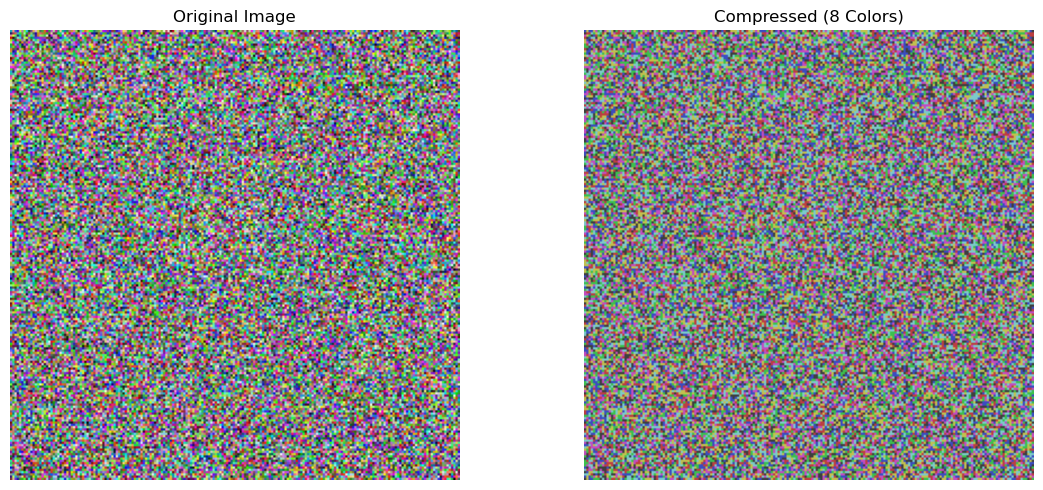

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(compressed_image)
axes[1].set_title("Compressed (8 Colors)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

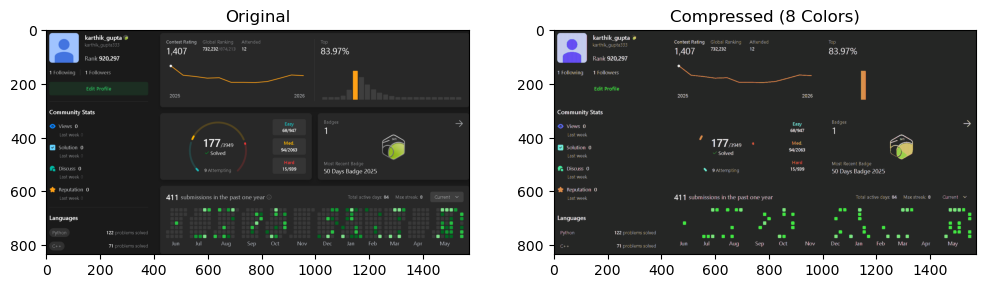

In [13]:
# Test with your own image
test_image = Image.open(r'C:\Users\k9481\OneDrive\Pictures\Screenshots\Screenshot 2026-06-06 120723.png')
test_image_array = np.array(test_image)

# Reshape and compress
pixels = test_image_array.reshape(-1, 3)
kmeans = KMeans(n_clusters=8, n_init=10, random_state=42)
kmeans.fit(pixels)
compressed = kmeans.cluster_centers_[kmeans.predict(pixels)].reshape(test_image_array.shape).astype(np.uint8)

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(test_image_array)
axes[0].set_title("Original")
axes[1].imshow(compressed)
axes[1].set_title("Compressed (8 Colors)")
plt.show()